## Statsforecast for GPU Utilization

### Without exogeneous variables

In [1]:
from statsforecast import StatsForecast

In [3]:
import pandas as pd

In [5]:
Y_df = pd.read_csv('data/gpu_slurm_metrics_10s_cleaned.csv') # load the data
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [6]:
Y_df['unique_id'] = Y_df['id_job'].astype(str) + '_gpu' + Y_df['gpu_index'].astype(str)

In [7]:
Y_df['timestamp'] = pd.to_datetime(Y_df['timestamp'])
Y_df = Y_df.sort_values(by=['unique_id', 'timestamp'])

In [8]:
# Create a numerical index 'ds' that starts from 0 for each series.
# This is crucial for Nixtla models and handles variable start times and durations.
Y_df['ds'] = Y_df.groupby('unique_id').cumcount()

In [9]:
Y_df['y'] = Y_df['utilization_gpu_pct']

In [10]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  ds                      1259185 non-null  int64         
 12  y              

In [11]:
# This is the standard format for Nixtla.
prepared_df = Y_df[['unique_id', 'ds', 'y']]

print("Data prepared successfully. Head of the DataFrame:")
print(prepared_df.head())
print(f"\nNumber of unique time series (job-gpu combinations): {prepared_df['unique_id'].nunique()}")

Data prepared successfully. Head of the DataFrame:
                  unique_id  ds         y
264388  10217518336509_gpu0   0  6.360656
471025  10217518336509_gpu0   1  0.435484
264389  10217518336509_gpu0   2  0.031915
471026  10217518336509_gpu0   3  0.063830
264390  10217518336509_gpu0   4  1.150538

Number of unique time series (job-gpu combinations): 414


In [12]:
Y_df.head()

,timestamp,gpu_index,utilization_gpu_pct,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W,id_job,time_start,time_end,unique_id,ds,y
264388,2021-06-07 20:24:30,0,6.360656,0.360656,65.180328,66.393443,54.939016,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,0,6.360656
471025,2021-06-07 20:24:30,0,0.435484,0.000000,40.000000,38.080645,46.433710,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,1,0.435484
264389,2021-06-07 20:24:40,0,0.031915,0.010638,63.638298,64.861702,53.556915,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,2,0.031915
471026,2021-06-07 20:24:40,0,0.063830,0.021277,40.000000,38.042553,46.569681,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,3,0.063830
264390,2021-06-07 20:24:50,0,1.150538,0.032258,62.311828,63.387097,52.611935,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,4,1.150538


In [13]:
# h = (5 minutes * 60 seconds/minute) / 10 seconds/sample = 30 steps
h = 30

# Split data into training and testing sets
# The test set is the last 'h' steps of EACH time series.
train_df = prepared_df.groupby('unique_id').head(-h)
test_df = prepared_df.groupby('unique_id').tail(h)

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 1246765
Test set size: 12420


In [14]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta

# seasonal_length=6 for 1 minute
sf_models = [
    AutoARIMA(season_length=6),
    AutoETS(season_length=6),
    AutoTheta(season_length=6)
]

sf = StatsForecast(
    models=sf_models,
    freq=1, # Since we created an integer 'ds' index
    n_jobs=-1 # Use all available cores
)

# 3. Get predictions
# The forecast method takes the training data and predicts 'h' steps for each series.
# Note: StatsForecast is smart and uses the last available data from train_df to forecast.
forecast_sf_df = sf.forecast(df=train_df, h=h)

# Merge with true values for evaluation
forecast_sf_df = forecast_sf_df.merge(test_df, on=['unique_id', 'ds'], how='left')

print("StatsForecast predictions:")
print(forecast_sf_df.head())

StatsForecast predictions:
             unique_id    ds  AutoARIMA    AutoETS  AutoTheta          y
0  10217518336509_gpu0  5048  93.664716  93.733114  93.711269  94.655914
1  10217518336509_gpu0  5049  93.660859  93.733004  93.589744  94.978723
2  10217518336509_gpu0  5050  93.661097  93.732900  93.628222  94.935484
3  10217518336509_gpu0  5051  93.661082  93.732803  93.618603  94.914894
4  10217518336509_gpu0  5052  93.661083  93.732712  93.687648  94.279570


In [15]:
forecast_sf_df

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta,y
0,10217518336509_gpu0,5048,93.664716,93.733114,93.711269,94.655914
1,10217518336509_gpu0,5049,93.660859,93.733004,93.589744,94.978723
2,10217518336509_gpu0,5050,93.661097,93.732900,93.628222,94.935484
3,10217518336509_gpu0,5051,93.661082,93.732803,93.618603,94.914894
4,10217518336509_gpu0,5052,93.661083,93.732712,93.687648,94.279570
...,...,...,...,...,...,...
12415,9976590120891_gpu1,14525,96.922748,97.065059,97.073560,96.072289
12416,9976590120891_gpu1,14526,96.074509,97.065059,97.086260,97.168675
12417,9976590120891_gpu1,14527,96.135934,97.065059,97.073634,96.626506
12418,9976590120891_gpu1,14528,96.955086,97.065059,97.055371,98.867470


In [16]:
fcst_no_e = forecast_sf_df[["unique_id", "ds", "AutoETS", "AutoTheta"]]

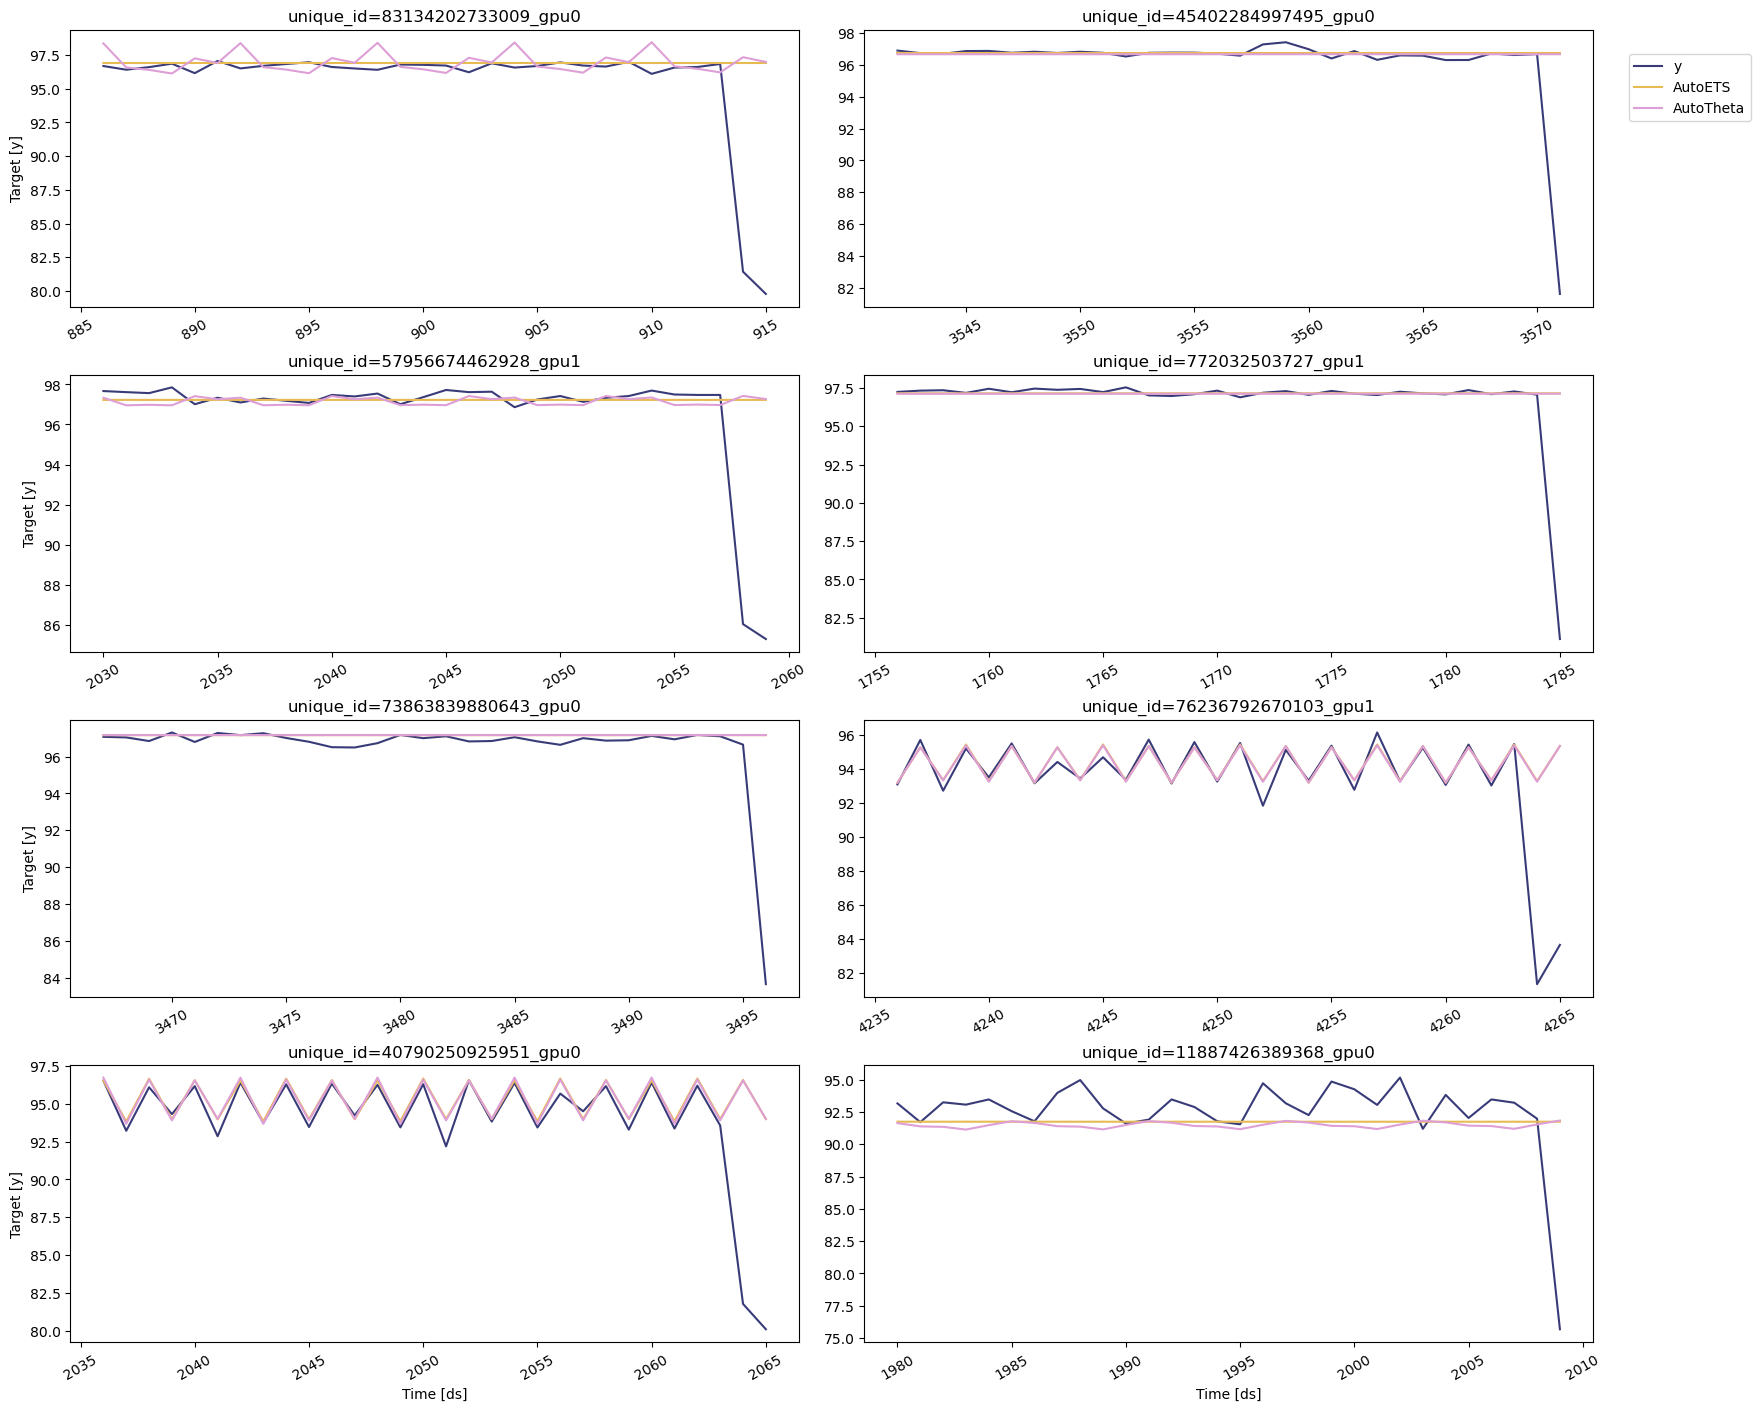

In [17]:
StatsForecast.plot(test_df, fcst_no_e, max_insample_length=30*2)

In [18]:
import polars as pl
import pandas as pd
import numpy as np
from utilsforecast.losses import mae, rmse, mse, mape, smape

def evaluate_forecast(df, y_col="y", id_col="unique_id", ds_col="ds"):
    # Detect all forecast model columns (exclude id, ds, y)
    model_cols = [c for c in df.columns if c not in [id_col, ds_col, y_col, "Unnamed: 0"]]
    
    # Convert pandas → polars
    pl_df = pl.from_pandas(df[[id_col, y_col] + model_cols])
    
    # -----------------
    # Per-series metrics
    # -----------------
    results = {
        "MAE": mae(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "RMSE": rmse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MSE": mse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MAPE": mape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "sMAPE": smape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
    }
    
    metrics_df = None
    for name, metric in results.items():
        metric = metric.rename({c: f"{c}_{name}" for c in metric.columns if c != id_col})
        metrics_df = metric if metrics_df is None else metrics_df.join(metric, on=id_col, how="inner")
    per_series_metrics = metrics_df.to_pandas()
    
    # -----------------
    # Global metrics
    # -----------------
    global_results = []
    y_true = df[y_col].values
    
    for model in model_cols:
        y_pred = df[model].values
        global_results.append({
            "Model": model,
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "MSE": np.mean((y_true - y_pred) ** 2),
            "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
            "sMAPE": np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))),
            "wMAPE": np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100,
        })
    
    global_metrics = pd.DataFrame(global_results)
    
    return per_series_metrics, global_metrics

# Example usage
per_series_metrics, global_metrics = evaluate_forecast(forecast_sf_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)


Per-series metrics:
              unique_id  AutoARIMA_MAE  AutoETS_MAE  AutoTheta_MAE  \
0  10217518336509_gpu0       2.451605     2.390054       2.463995   
1  10217518336509_gpu1       1.878616     1.804886       1.820434   
2  10297115157410_gpu1       0.825499     0.816801       0.815901   
3  10612452483078_gpu0       1.174242     1.062393       1.063422   
4  10612452483078_gpu1       1.130905     1.174588       1.172246   

   AutoARIMA_RMSE  AutoETS_RMSE  AutoTheta_RMSE  AutoARIMA_MSE  AutoETS_MSE  \
0        5.500946      5.505538        5.507820      30.260404    30.310954   
1        6.040135      6.132250        6.148423      36.483236    37.604495   
2        3.534229      3.533303        3.534108      12.490773    12.484227   
3        4.980247      5.006444        5.007168      24.802858    25.064477   
4        5.313863      5.305895        5.307012      28.237142    28.152524   

   AutoTheta_MSE  AutoARIMA_MAPE  AutoETS_MAPE  AutoTheta_MAPE  \
0      30.336076       

/tmp/ipykernel_28325/2923799021.py:43: RuntimeWarning: divide by zero encountered in divide
  "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,


### With exogeneous regressors

In [19]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  ds                      1259185 non-null  int64         
 12  y              

In [20]:
Y_ts = Y_df[['unique_id', 'ds', 'y']]

In [21]:
exog_vars = ['utilization_memory_pct', 'temperature_gpu', 'temperature_memory', 'power_draw_W']
X_ts = Y_df[['unique_id', 'ds'] + exog_vars]

In [22]:
X_ts['unique_id'] = X_ts.unique_id.astype(str)
X_ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   unique_id               1259185 non-null  object 
 1   ds                      1259185 non-null  int64  
 2   utilization_memory_pct  1259185 non-null  float64
 3   temperature_gpu         1259185 non-null  float64
 4   temperature_memory      1259185 non-null  float64
 5   power_draw_W            1259185 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 67.2+ MB


/tmp/ipykernel_28325/1014213204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_ts['unique_id'] = X_ts.unique_id.astype(str)


In [23]:
# h = (5 minutes * 60 seconds/minute) / 10 seconds/sample = 30 steps
h = 30

# Split data into training and testing sets
# The test set is the last 'h' steps of EACH time series.
Y_train = Y_ts.groupby('unique_id').head(-h)
Y_test = Y_ts.groupby('unique_id').tail(h)

X_train = X_ts.groupby('unique_id').head(-h)
X_test = X_ts.groupby('unique_id').tail(h)

print(f"Training set size: {len(Y_train)}")
print(f"Test set size: {len(Y_test)}")

Training set size: 1246765
Test set size: 12420


In [24]:
train = Y_train.merge(X_ts, how = 'left', on = ['unique_id', 'ds']) 
train.head()

,unique_id,ds,y,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W
0,10217518336509_gpu0,0,6.360656,0.360656,65.180328,66.393443,54.939016
1,10217518336509_gpu0,1,0.435484,0.000000,40.000000,38.080645,46.433710
2,10217518336509_gpu0,2,0.031915,0.010638,63.638298,64.861702,53.556915
3,10217518336509_gpu0,3,0.063830,0.021277,40.000000,38.042553,46.569681
4,10217518336509_gpu0,4,1.150538,0.032258,62.311828,63.387097,52.611935


In [25]:
X_test.head()

,unique_id,ds,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W
266912,10217518336509_gpu0,5048,32.516129,67.956989,70.602151,167.222043
473549,10217518336509_gpu0,5049,32.851064,68.159574,68.489362,182.227021
266913,10217518336509_gpu0,5050,32.602151,67.784946,70.408602,170.289140
473550,10217518336509_gpu0,5051,33.329787,68.297872,68.776596,183.194681
266914,10217518336509_gpu0,5052,32.526882,68.010753,70.827957,171.555484


In [26]:
# seasonal_length=6 for 1 minute
sf_models = [
    AutoARIMA(season_length=6),
    AutoETS(season_length=6),
    AutoTheta(season_length=6)
]

sf = StatsForecast(
    models=sf_models,
    freq=1, # Since we created an integer 'ds' index
    n_jobs=-1 # Use all available cores
)

In [27]:
horizon = 30

fcst = sf.forecast(df=train, h=horizon, X_df=X_test)
fcst.head()

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta
0,10217518336509_gpu0,5048,93.850326,93.733114,93.711269
1,10217518336509_gpu0,5049,94.329221,93.733004,93.589744
2,10217518336509_gpu0,5050,94.395725,93.732900,93.628222
3,10217518336509_gpu0,5051,95.249313,93.732803,93.618603
4,10217518336509_gpu0,5052,94.662197,93.732712,93.687648


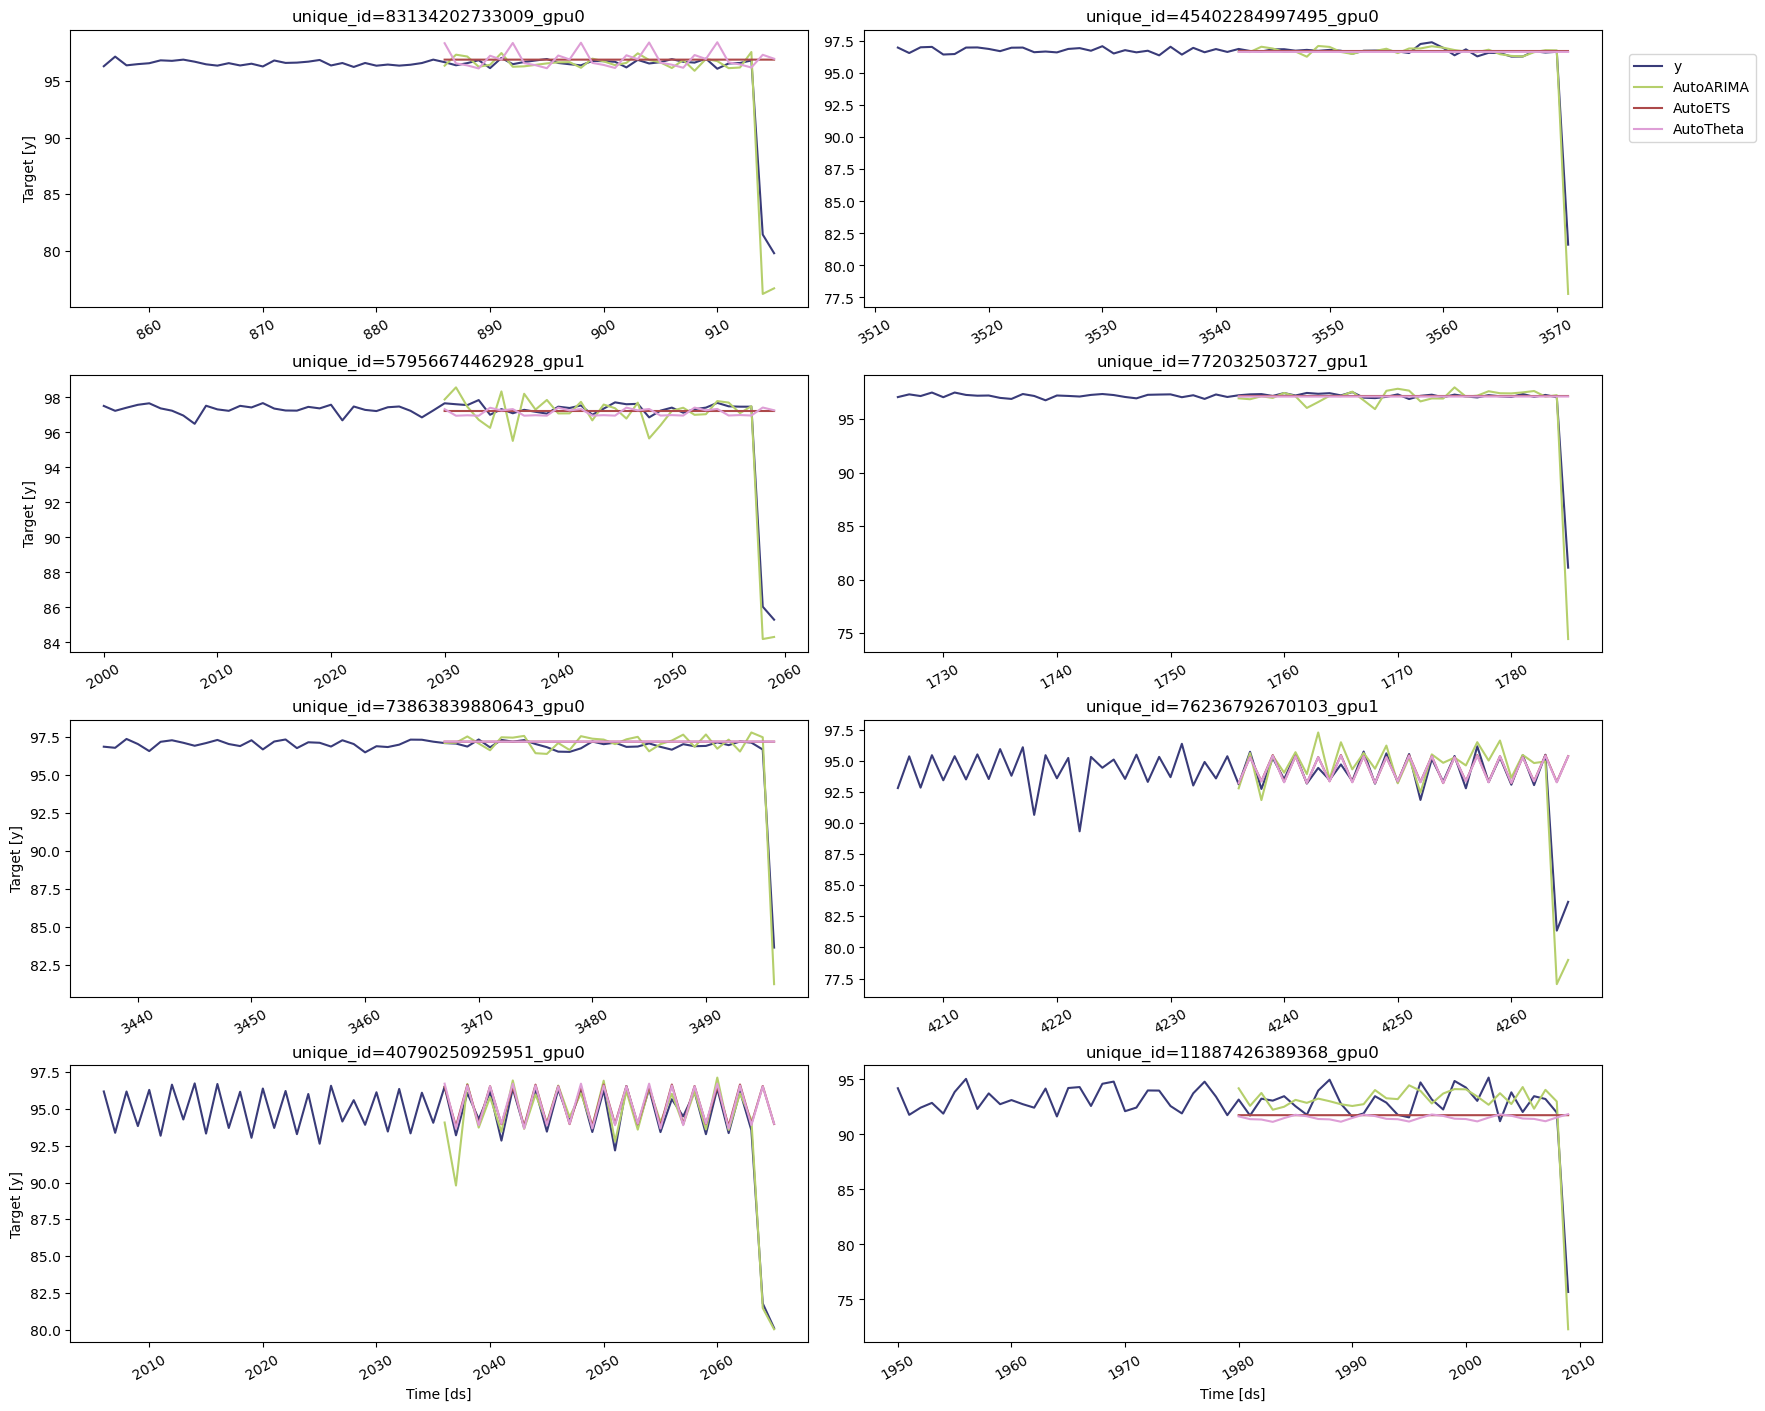

In [28]:
StatsForecast.plot(Y_ts, fcst, max_insample_length=30*2)

In [29]:
res = Y_test.merge(fcst, how='left', on=['unique_id', 'ds'])
res.head()

,unique_id,ds,y,AutoARIMA,AutoETS,AutoTheta
0,10217518336509_gpu0,5048,94.655914,93.850326,93.733114,93.711269
1,10217518336509_gpu0,5049,94.978723,94.329221,93.733004,93.589744
2,10217518336509_gpu0,5050,94.935484,94.395725,93.732900,93.628222
3,10217518336509_gpu0,5051,94.914894,95.249313,93.732803,93.618603
4,10217518336509_gpu0,5052,94.279570,94.662197,93.732712,93.687648


In [30]:
per_series_metrics, global_metrics = evaluate_forecast(res)

print("Per-series metrics:")
print(per_series_metrics.head())

print("\nGlobal metrics:")
print(global_metrics)

Per-series metrics:
             unique_id  AutoARIMA_MAE  AutoETS_MAE  AutoTheta_MAE  \
0  10217518336509_gpu0       0.567910     2.390054       2.463995   
1  10217518336509_gpu1       0.634697     1.804886       1.820434   
2  10297115157410_gpu1       0.598825     0.816801       0.815901   
3  10612452483078_gpu0       0.410832     1.062393       1.063422   
4  10612452483078_gpu1       0.306080     1.174588       1.172246   

   AutoARIMA_RMSE  AutoETS_RMSE  AutoTheta_RMSE  AutoARIMA_MSE  AutoETS_MSE  \
0        0.639121      5.505538        5.507820       0.408476    30.310954   
1        1.133957      6.132250        6.148423       1.285857    37.604495   
2        1.541035      3.533303        3.534108       2.374787    12.484227   
3        0.621301      5.006444        5.007168       0.386014    25.064477   
4        0.507798      5.305895        5.307012       0.257859    28.152524   

   AutoTheta_MSE  AutoARIMA_MAPE  AutoETS_MAPE  AutoTheta_MAPE  \
0      30.336076        

/tmp/ipykernel_28325/2923799021.py:43: RuntimeWarning: divide by zero encountered in divide
  "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
